# Exploratory Data Analysis — Time Series & Correlation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)

RAW_DIR = Path("data/raw")

SERIES = {
    "INDPRO":  "Industrial Production",
    "RSAFS":   "Retail Sales",
    "PAYEMS":  "Nonfarm Payrolls",
    "UNRATE":  "Unemployment Rate",
    "HOUST":   "Housing Starts",
    "PCE":     "Personal Consumption",
    "DGORDER": "Durable Goods Orders",
    "T10Y2Y":  "10Y-2Y Spread",
}
TARGET = "A191RL1Q225SBEA"

def load(code):
    s = pd.read_csv(RAW_DIR / f"{code}.csv", index_col=0, parse_dates=True).iloc[:, 0]
    s.name = code
    return s.sort_index()

raw = {code: load(code) for code in SERIES}
gdp_growth = load(TARGET)
gdp_growth.name = "GDP Growth"

## 1. Time Series Overview — Key Macro Indicators vs GDP Growth
Each plot shows one indicator with quarterly GDP growth overlaid as grey bars to visually identify leading/lagging relationships.

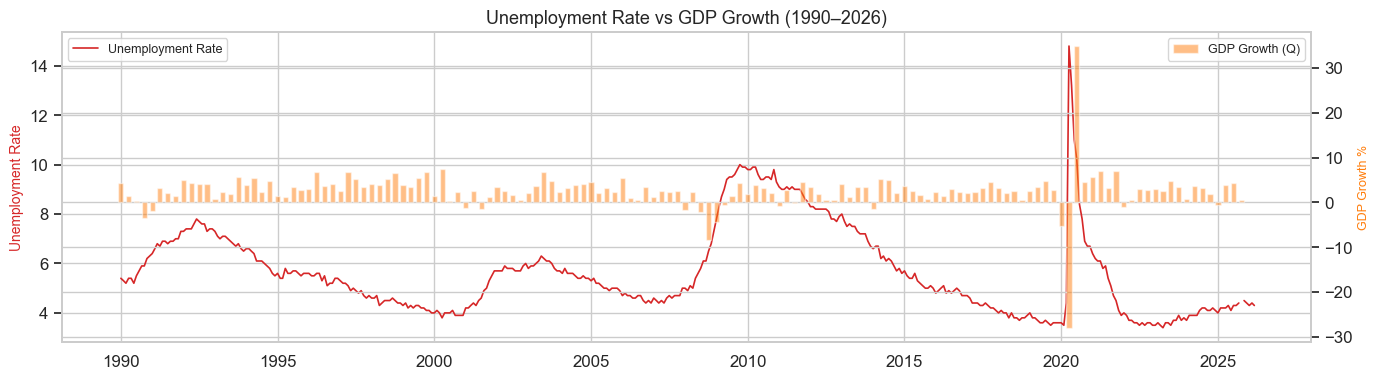

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
s = raw["UNRATE"]
ax.plot(s.index, s.values, linewidth=1.2, color="tab:red", label=SERIES["UNRATE"])
ax.set_ylabel(SERIES["UNRATE"], fontsize=10, color="tab:red")
ax.legend(loc="upper left", fontsize=9)

ax2 = ax.twinx()
ax2.bar(gdp_growth.index, gdp_growth.values, width=60, alpha=0.5, color="tab:orange", label="GDP Growth (Q)")
ax2.set_ylabel("GDP Growth %", fontsize=9, color="tab:orange")
ax2.legend(loc="upper right", fontsize=9)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Unemployment Rate vs GDP Growth (1990–2026)", fontsize=13)
plt.tight_layout()
plt.show()

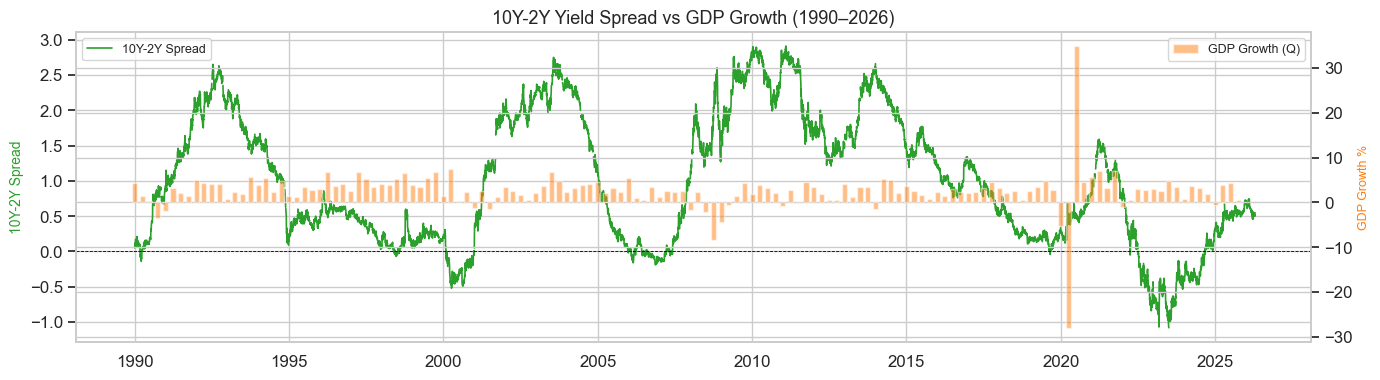

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
s = raw["T10Y2Y"]
ax.plot(s.index, s.values, linewidth=1.2, color="tab:green", label=SERIES["T10Y2Y"])
ax.set_ylabel(SERIES["T10Y2Y"], fontsize=10, color="tab:green")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.legend(loc="upper left", fontsize=9)

ax2 = ax.twinx()
ax2.bar(gdp_growth.index, gdp_growth.values, width=60, alpha=0.5, color="tab:orange", label="GDP Growth (Q)")
ax2.set_ylabel("GDP Growth %", fontsize=9, color="tab:orange")
ax2.legend(loc="upper right", fontsize=9)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10Y-2Y Yield Spread vs GDP Growth (1990–2026)", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Correlation Heatmap — Quarterly Aggregated Indicators vs GDP Growth
Resamples all monthly/daily indicators to quarterly frequency and computes Pearson correlations to reveal which variables move together and which are most correlated with GDP growth.

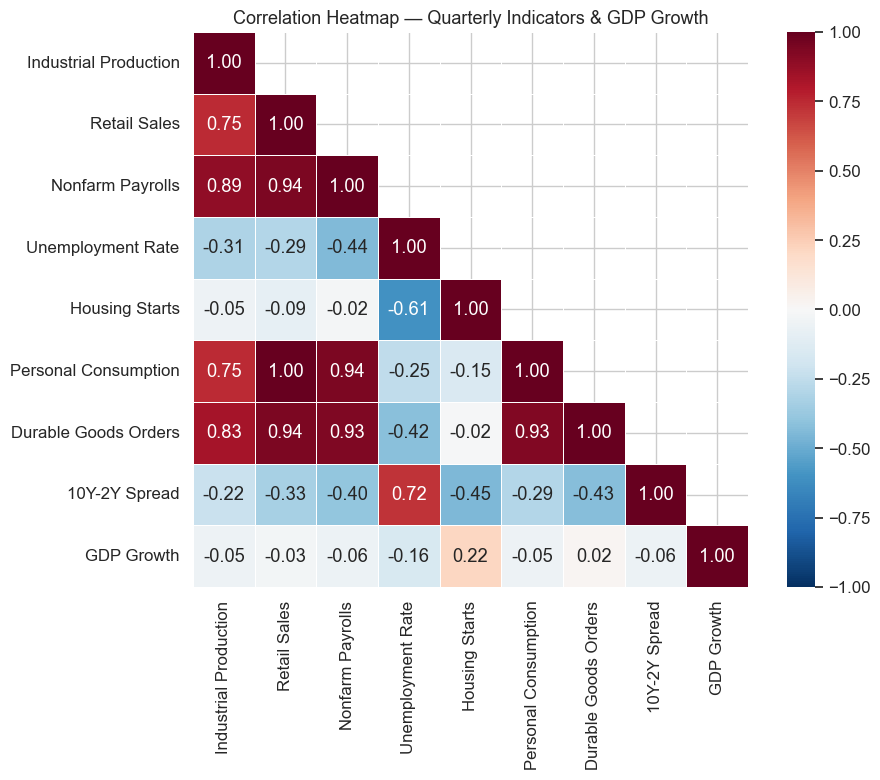

In [3]:
quarterly = pd.DataFrame()
for code, s in raw.items():
    quarterly[SERIES[code]] = s.resample("QS").mean()

quarterly["GDP Growth"] = gdp_growth
quarterly = quarterly.dropna()

corr = quarterly.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Quarterly Indicators & GDP Growth", fontsize=13)
plt.tight_layout()
plt.show()